                                Cognifyz: Internship Program in the field of Data Science

LEVEL3 - TASK2 : Customer Preference Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set(color_codes=True)
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore")

In [3]:
file_path = r"E:\COLLEGGE\6 SEMESTER\Internship cognifyz\Dataset .csv"

try:
     dataset = pd.read_csv(file_path, sep=",", on_bad_lines='skip', encoding="utf-8-sig")
     print("File read sucessfully")
except FileNotFoundError:
     print(f"File not found: {file_path}")

File read sucessfully


In [4]:
dataset.head(2)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


In [5]:
dataset.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


Analyze the relationship between the type of  cuisine and the restaurant's rating

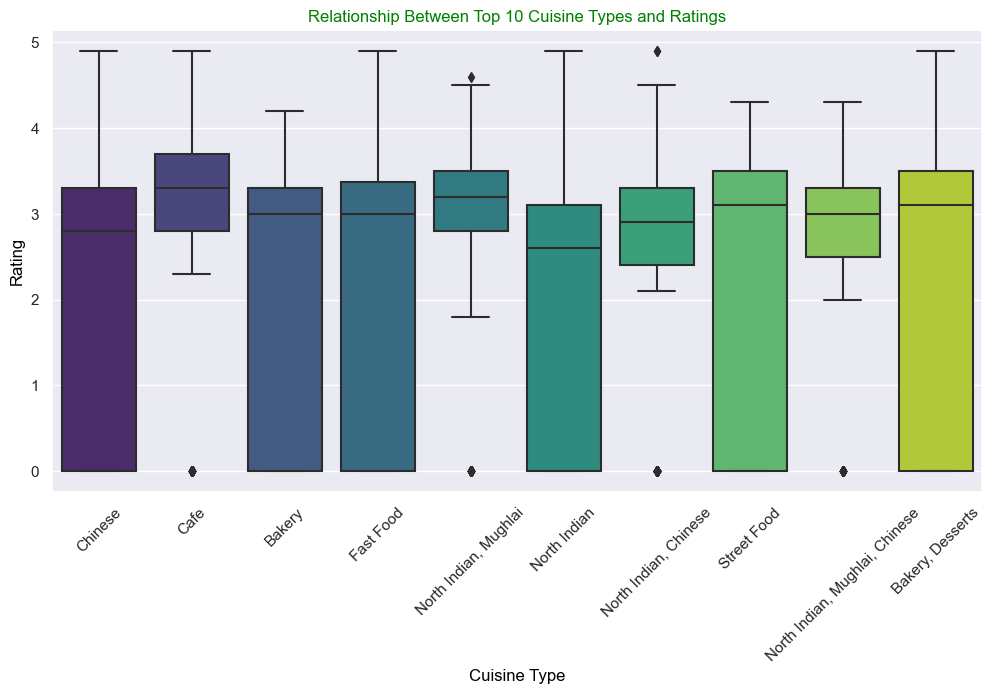

In [6]:
cuisines = dataset["Cuisines"]

cuisines.value_counts().head(10)

top_10_cuisines = cuisines.value_counts().head(10).index

cuisine_ratings = pd.DataFrame({"cuisine": cuisines, "Rating": dataset["Aggregate rating"]})

cuisine_ratings_top_10 = cuisine_ratings[cuisine_ratings["cuisine"].isin(top_10_cuisines)]

plt.figure(figsize=(12, 6))
sns.boxplot(x="cuisine", y="Rating", data=cuisine_ratings_top_10, palette="viridis")
plt.title("Relationship Between Top 10 Cuisine Types and Ratings", color="green")
plt.xlabel("Cuisine Type", color="black")
plt.ylabel("Rating", color="black")
plt.xticks(rotation=45)
plt.show()


Identify the most popular cuisines among  customers based on the number of votes

In [7]:

cuisine_votes = pd.DataFrame({"Cuisine": cuisines, "Votes": dataset["Votes"]})

cuisine_votes_sum = cuisine_votes.groupby("Cuisine")["Votes"].sum()

popular_cuisines = cuisine_votes_sum.sort_values(ascending=False)

print("Top 10 Most Popular Cuisines Based on Number of Votes:")
print(popular_cuisines.head(10))


Top 10 Most Popular Cuisines Based on Number of Votes:
Cuisine
North Indian, Mughlai             53747
North Indian                      46241
North Indian, Chinese             42012
Cafe                              30657
Chinese                           21925
North Indian, Mughlai, Chinese    20115
Fast Food                         17852
South Indian                      16433
Mughlai, North Indian             15275
Italian                           14799
Name: Votes, dtype: int64


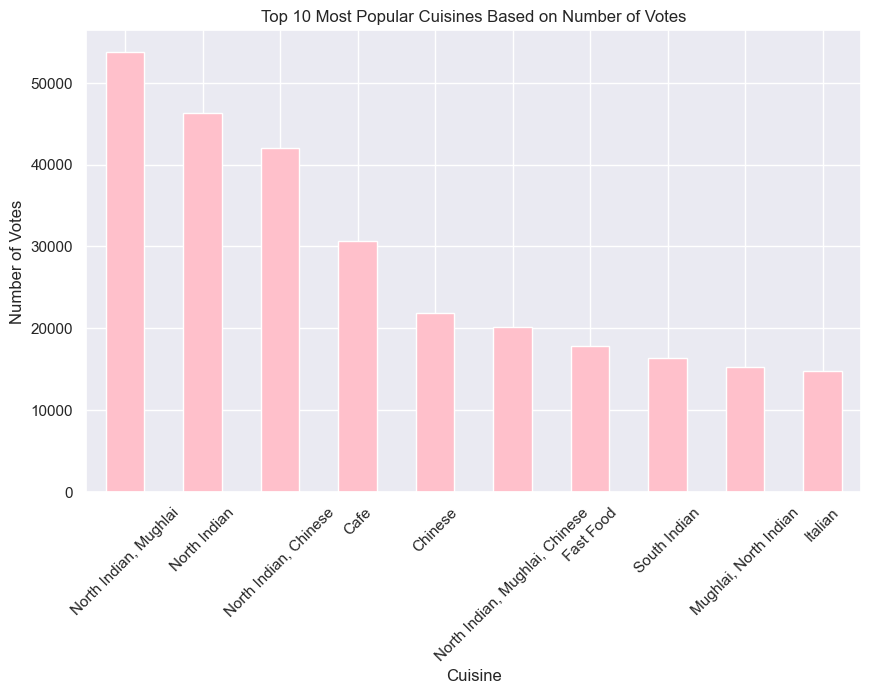

In [8]:
plt.figure(figsize=(10, 6))
popular_cuisines.head(10).plot(kind="bar", color="pink")
plt.title("Top 10 Most Popular Cuisines Based on Number of Votes")
plt.xlabel("Cuisine")
plt.ylabel("Number of Votes")
plt.xticks(rotation=45)
plt.show()


 Determine if there are any specific cuisines that tend to receive higher ratings

In [10]:
cuisine_ratings = pd.DataFrame({"Cuisine": cuisines, "Rating": dataset["Aggregate rating"]})

average_rating_by_cuisine = cuisine_ratings.groupby("Cuisine")["Rating"].mean()

sorted_cuisines_by_rating = average_rating_by_cuisine.sort_values(ascending=False)

print("Top 10 Cuisines with the Highest Average Ratings: ")
print(sorted_cuisines_by_rating.head(10))


Top 10 Cuisines with the Highest Average Ratings: 
Cuisine
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Rating, dtype: float64


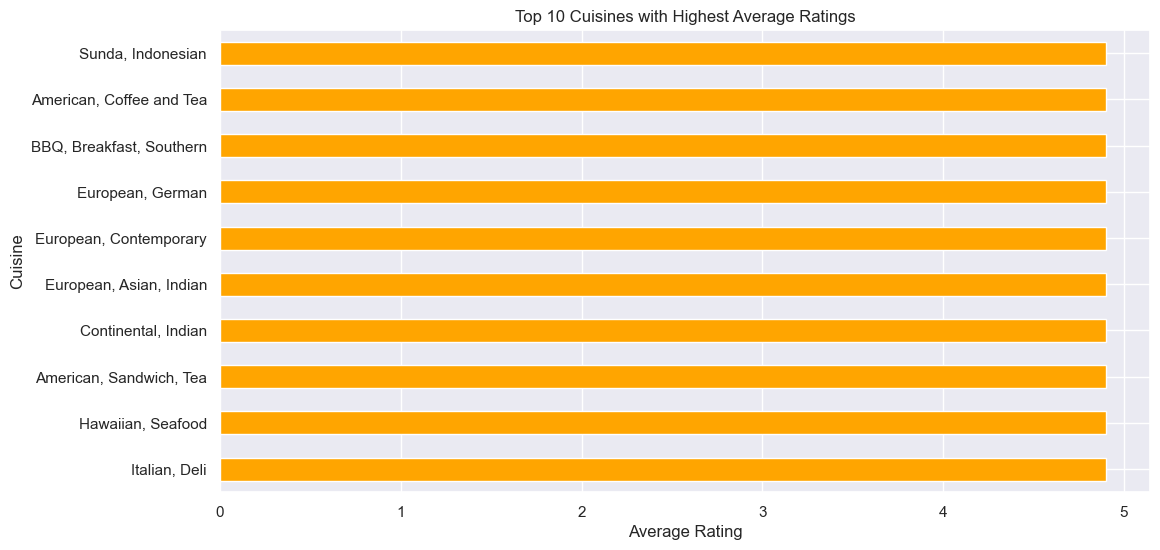

In [11]:
plt.figure(figsize=(12, 6))
sorted_cuisines_by_rating.head(10).plot(kind="barh", color="orange")
plt.title("Top 10 Cuisines with Highest Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.show()
